In [1]:
import sleap
import sys
import cmath
import json
import os

sys.path.append('..')
from python.polygon_based_correction import *
from eval.eval import *
from python.dataset_conversion import *

sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


training data -> SLEAP -> SLEAP output -> manual correction -> autoencoder -> final output

manual correction steps (instead of using the tracking function from SLEAP):
1. identify mispredicted points (points predicted at where there isn't a tentacle): prediction score + displacement 
2. assign identity to the rest of the points using optical flow 
3. interpolate missing points using average displacement/optical flow from its two neighbors
4. run polygon-based correction on all points to ensure maximal global alignment with the previous frame

In [4]:
training_json_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/models/250221_022817.centroid.n=4149/training_config.json'
# training_json_path = '/home/mingxiao/Desktop/jellyfish/label/models/250214_122024.single_instance.n=1653/training_config.json'
training_config = json.load(open(training_json_path))

In [5]:
val_indices = np.array(training_config['data']['labels']['validation_inds'])
train_indices = np.array(training_config['data']['labels']['training_inds'])
print(val_indices.shape)
print(train_indices.shape)

(415,)
(3734,)


In [2]:
single_animal_dataset_path = '/home/mingxiao/Desktop/jellyfish/label/animal_1_labels.v002.slp'
single_animal_dataset = sleap.load_file(single_animal_dataset_path)
print(single_animal_dataset)
multi_animal_dataset = single2multi(single_animal_dataset)
print(multi_animal_dataset)

Labels(labeled_frames=8089, videos=1, skeletons=1, tracks=0)
Tentacle count: 17
Average mouth location: [86.18999969 79.86647831]
Labels(labeled_frames=1653, videos=1, skeletons=1, tracks=17)


In [4]:
single_animal_dataset.skeleton

Skeleton(name='Skeleton-1', description='None', nodes=['Mouth', 'TB1', 'TB2', 'TB3', 'TB4', 'TB5', 'TB6', 'TB7', 'TB8', 'TB9', 'TB10', 'TB11', 'TB12', 'TB13', 'TB14', 'TB15', 'TB16', 'TB17'], edges=[('Mouth', 'TB1'), ('Mouth', 'TB2'), ('Mouth', 'TB3'), ('Mouth', 'TB4'), ('Mouth', 'TB5'), ('Mouth', 'TB6'), ('Mouth', 'TB7'), ('Mouth', 'TB8'), ('Mouth', 'TB9'), ('Mouth', 'TB10'), ('Mouth', 'TB11'), ('Mouth', 'TB12'), ('Mouth', 'TB13'), ('Mouth', 'TB14'), ('Mouth', 'TB15'), ('Mouth', 'TB16'), ('Mouth', 'TB17')], symmetries=[])

In [3]:
src_multi_animal_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0.slp'
src_multi_animal_dataset = sleap.load_file(src_multi_animal_dataset_path)
print(src_multi_animal_dataset)
src_single_animal_dataset = multi2single(src_multi_animal_dataset)
print(src_single_animal_dataset)

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)
Tentacle count: 17
Labels(labeled_frames=5202, videos=1, skeletons=1, tracks=0)


In [5]:
src_single_animal_dataset.skeleton

Skeleton(name='jellyfish', description='None', nodes=['Mouth', 'TB1', 'TB2', 'TB3', 'TB4', 'TB5', 'TB6', 'TB7', 'TB8', 'TB9', 'TB10', 'TB11', 'TB12', 'TB13', 'TB14', 'TB15', 'TB16', 'TB17'], edges=[('Mouth', 'TB1'), ('Mouth', 'TB2'), ('Mouth', 'TB3'), ('Mouth', 'TB4'), ('Mouth', 'TB5'), ('Mouth', 'TB6'), ('Mouth', 'TB7'), ('Mouth', 'TB8'), ('Mouth', 'TB9'), ('Mouth', 'TB10'), ('Mouth', 'TB11'), ('Mouth', 'TB12'), ('Mouth', 'TB13'), ('Mouth', 'TB14'), ('Mouth', 'TB15'), ('Mouth', 'TB16'), ('Mouth', 'TB17')], symmetries=[])

In [9]:
multi_v11_dataset_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/multifish_animal_1_v11.slp'
multi_v11_dataset = sleap.load_file(multi_v11_dataset_path)
print(multi_v11_dataset)

Labels(labeled_frames=4149, videos=1, skeletons=1, tracks=17)


In [18]:
single_v10_dataset_path = '/home/mingxiao/Desktop/jellyfish/label/animal_1_labels_v11.slp'
single_v10_dataset = multi2single(multi_v11_dataset, save_path=single_v10_dataset_path)
print(single_v10_dataset)

Tentacle count: 17
Labels(labeled_frames=4144, videos=1, skeletons=1, tracks=0)


(9000, 17, 2)
total_range_length: 4264


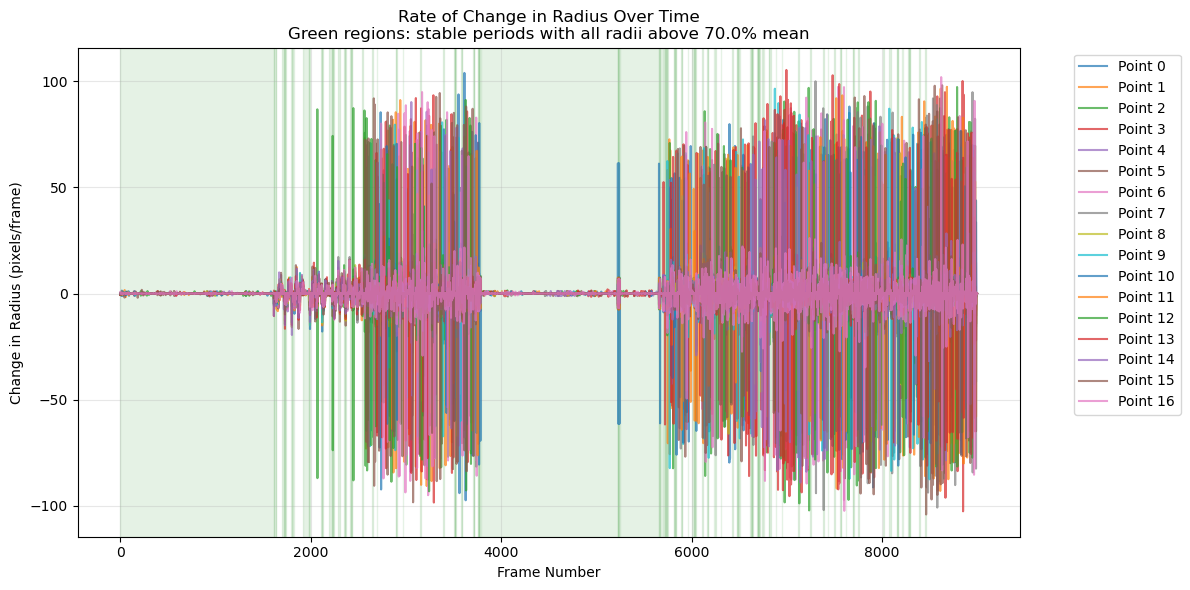

100%|██████████| 9000/9000 [00:03<00:00, 2371.23it/s]


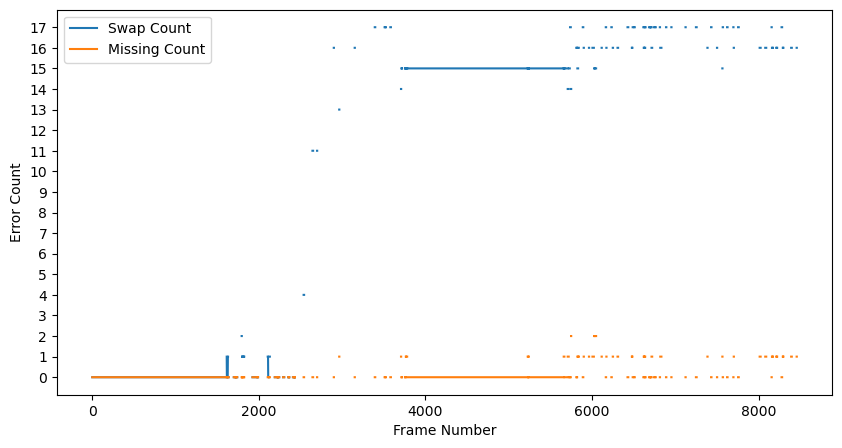

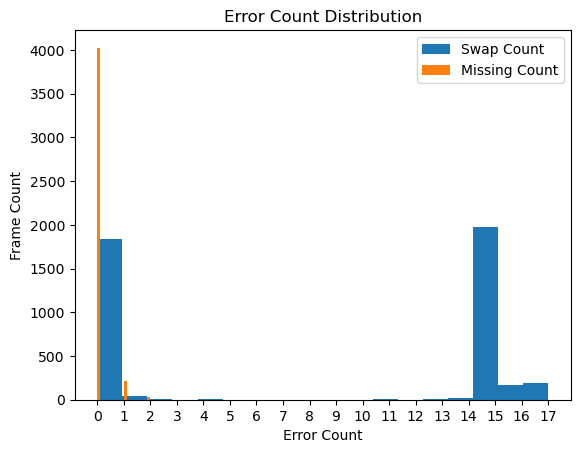

In [17]:
tracked_pts_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/manual_5min_c0_tracked_points.npy'
tracked_points = np.load(tracked_pts_path)
print(tracked_points.shape)
swap_cnt_lst, missing_cnt_lst,filtered_ranges = eval_dataset_from_points(tracked_points)

## multi-animal model

### 4k, uncorrected

In [2]:
# multi_4k_points_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/predictions/multifish_animal_1_v10_tracked_points.npy'
multi_4k_points_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/predictions/multifish_animal_1_v10_predicted_points.npy'
multi_4k_points = np.load(multi_4k_points_path)
print(multi_4k_points.shape)
# swap_cnt_lst, missing_cnt_lst,filtered_ranges = eval_dataset_from_points(multi_4k_points)

(3240000, 17, 2)


(9000, 17, 2)
total_range_length: 431


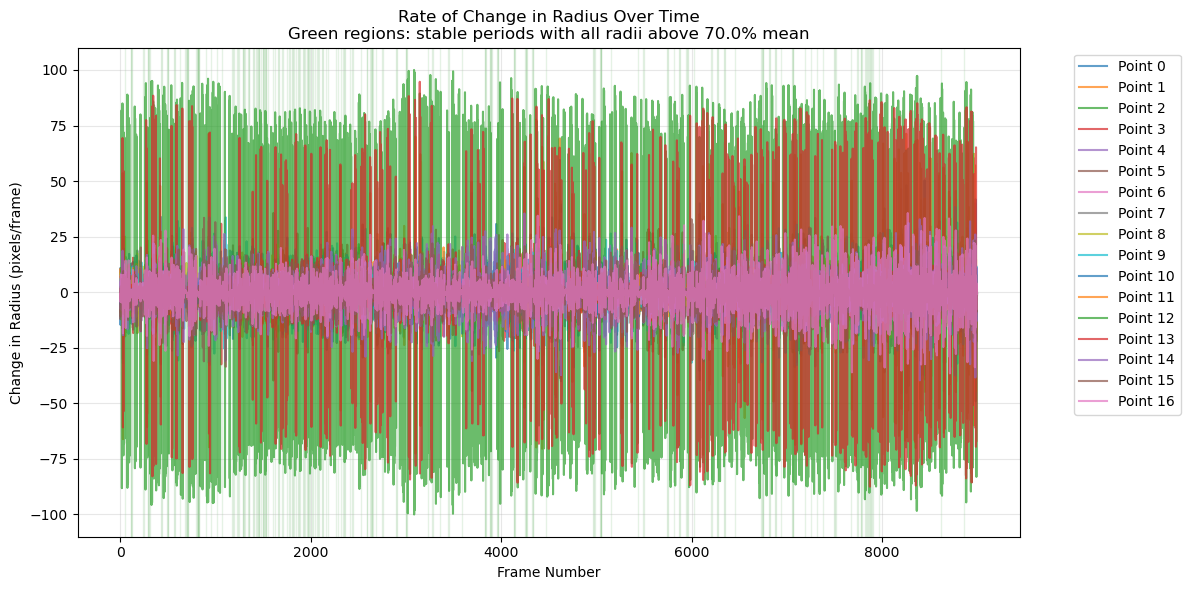

100%|██████████| 9000/9000 [00:38<00:00, 235.74it/s] 


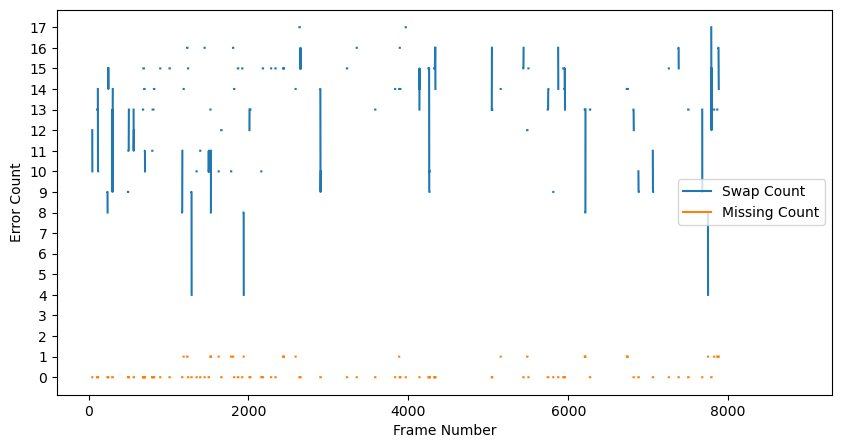

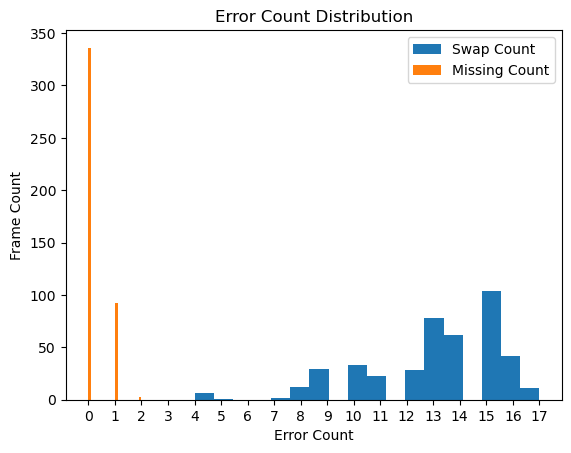

In [4]:
start_idx = 150 * 60 * 60
end_idx = 150 * 60 * 61
multi_pts_clip = multi_4k_points[start_idx:end_idx]
print(multi_pts_clip.shape)
swap_cnt_lst, missing_cnt_lst,filtered_ranges = eval_dataset_from_points(multi_pts_clip, method='polygon')

In [5]:
a1_1h_1min_dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/a1_1h_1m.slp'
a1_1h_1min_dataset = sleap.load_file(a1_1h_1min_dataset_path)
print(a1_1h_1min_dataset)

Labels(labeled_frames=0, videos=1, skeletons=0, tracks=0)


In [6]:
a1_1h_1min_w_pts_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_1m_w_pts.slp'
a1_1h_1min_w_pts = multi_model_dataset_with_points(a1_1h_1min_dataset, multi_pts_clip, save_path=a1_1h_1min_w_pts_path)
print(a1_1h_1min_w_pts)

Tentacle count: 17
Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)


### test dataset only

In [2]:
dataset_path = "/home/mingxiao/Desktop/jellyfish/label/multifish/multifish_animal_1_v10.slp"
# dataset_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/predictions/multifish_animal_1_v10.slp.250221_051111.predictions.slp'
dataset = sleap.load_file(dataset_path)
print(dataset)

Labels(labeled_frames=4149, videos=1, skeletons=1, tracks=0)


In [6]:
all_lbfs = dataset.labeled_frames
# print(all_lbfs.shape)
print(len(all_lbfs))
test_lbfs = [all_lbfs[i] for i in val_indices]
test_lbf_indices = [lbf.frame_idx for lbf in test_lbfs]
# print(test_lbfs.shape)
print(len(test_lbfs))

4149
415


In [7]:
first_frame_pts = get_all_untracked_points_from_lbfs(all_lbfs[:1], interpolate=False, reorder=False, use_labeled_only=True)[0]
print(first_frame_pts.shape)
reorder_idx = poly_4(first_frame_pts)
print(reorder_idx)

all_untracked_points shape: (1, 17, 2)


1it [00:00, 134.68it/s]

Missing point count: 0
(17, 2)
[13, 14, 15, 16, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [8]:
test_labeled_points = get_all_untracked_points_from_lbfs(test_lbfs, interpolate=False, reorder=False, use_labeled_only=True)
# test_labeled_points = test_labeled_points[:, reorder_idx]
print(test_labeled_points.shape)

all_untracked_points shape: (415, 17, 2)


415it [00:00, 786.34it/s]

Missing point count: 0
(415, 17, 2)


In [9]:
multi_4k_points_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/predictions/multifish_animal_1_v10_predicted_points.npy'
multi_4k_points = np.load(multi_4k_points_path)
# [:, 1:, :]
print(multi_4k_points.shape)
# swap_cnt_lst, missing_cnt_lst,filtered_ranges = eval_discrete_points(multi_4k_points, test_lbf_indices, method='polygon', count_missing=True)


(3240000, 17, 2)


#### regular eval

(415, 17, 2)


  0%|          | 0/415 [00:00<?, ?it/s]

100%|██████████| 415/415 [00:38<00:00, 10.75it/s]


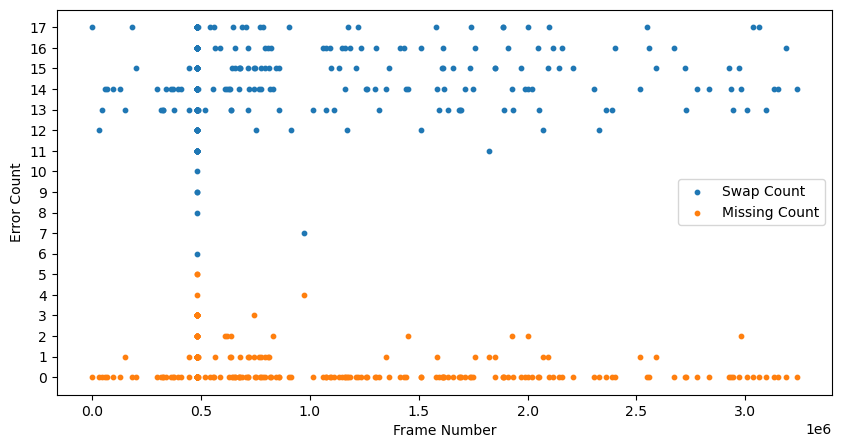

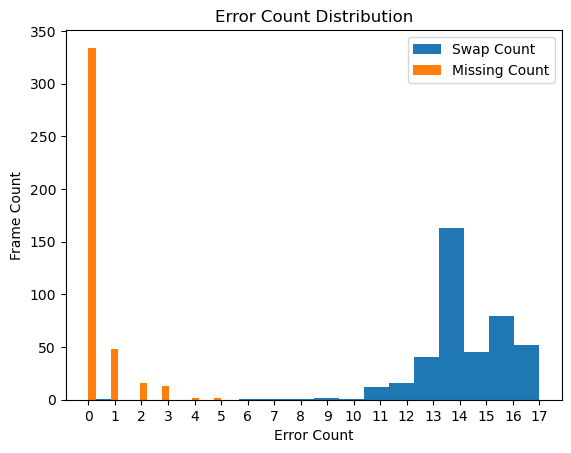

In [21]:
test_predicted_points = multi_4k_points[test_lbf_indices]
test_predicted_points = test_predicted_points[:, poly_4(test_predicted_points[0])]
print(test_predicted_points.shape)
swap_cnt_lst, missing_cnt_lst = eval_discrete_points(test_predicted_points, test_lbf_indices, method='polygon', count_missing=True)

#### compare with ground truth

In [16]:
def compare_with_gt(predicted_points, labeled_points, frame_indices, dist_thresh=10):
    assert predicted_points.shape == labeled_points.shape, f'predicted_points.shape: {predicted_points.shape}, labeled_points.shape: {labeled_points.shape}'
    swap_cnt_lst = []
    missing_cnt_lst = []
    frame_cnt, tb_cnt = predicted_points.shape[:2]
    for i in range(frame_cnt):
        swap_cnt = 0
        missing_cnt = 0
        used_nn = []
        for j in range(tb_cnt):
            x, y = predicted_points[i, j]
            # x_gt, y_gt = labeled_points[i, j]
            if np.isnan(x) or np.isnan(y) or x + y == 0:
                missing_cnt += 1
                continue
            diff = labeled_points[i] - predicted_points[i, j]
            dists = np.hypot(diff[:, 0], diff[:, 1])
            min_dist_idx = np.argmin(dists)
            min_dist = dists[min_dist_idx]
            if min_dist > dist_thresh or min_dist_idx in used_nn:
                swap_cnt += 1
            else:
                used_nn.append(min_dist_idx)
        swap_cnt_lst.append(swap_cnt)
        missing_cnt_lst.append(missing_cnt)
    
    plt.figure(figsize=(10, 5))
    plt.scatter(frame_indices, swap_cnt_lst, s=10, label='Swap Count')
    plt.scatter(frame_indices, missing_cnt_lst, s=10, label='Missing Count')
    plt.legend()
    plt.xlabel('Frame Number')
    plt.ylabel('Error Count')
    plt.yticks(range(tb_cnt + 1))
    plt.show()
    
    plot_error_count_distribution(swap_cnt_lst, missing_cnt_lst, tb_cnt=tb_cnt)
    
    return swap_cnt_lst, missing_cnt_lst

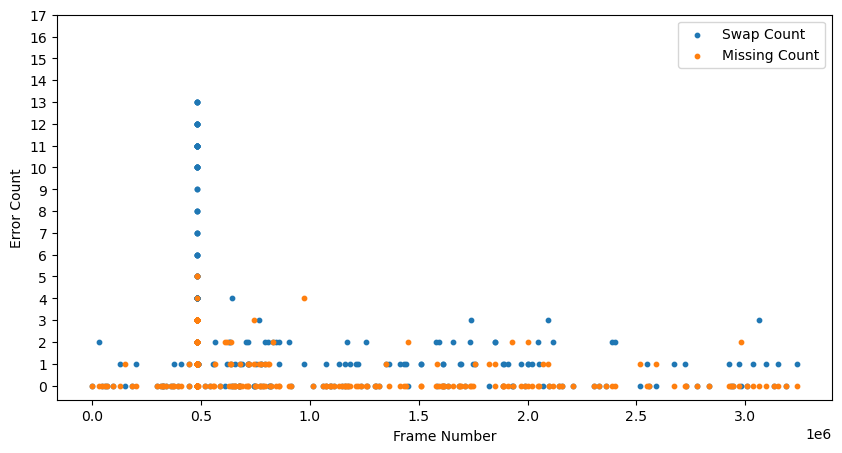

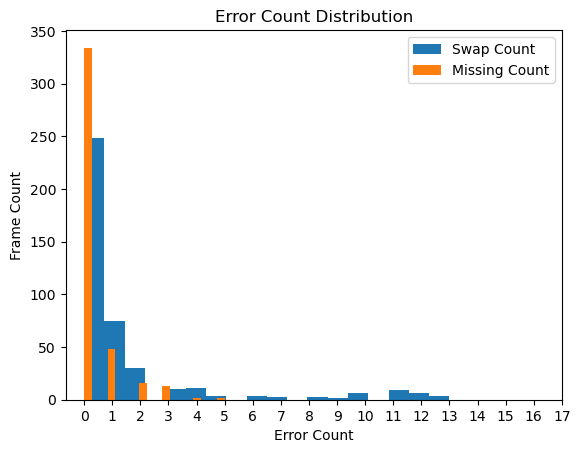

In [22]:
swap_cnt_lst, missing_cnt_lst = compare_with_gt(test_predicted_points, test_labeled_points, test_lbf_indices, dist_thresh=2)

In [14]:
test_labeled_points_corrected = polygon_correction_with_points(test_labeled_points)

100%|██████████| 415/415 [00:16<00:00, 25.91it/s]


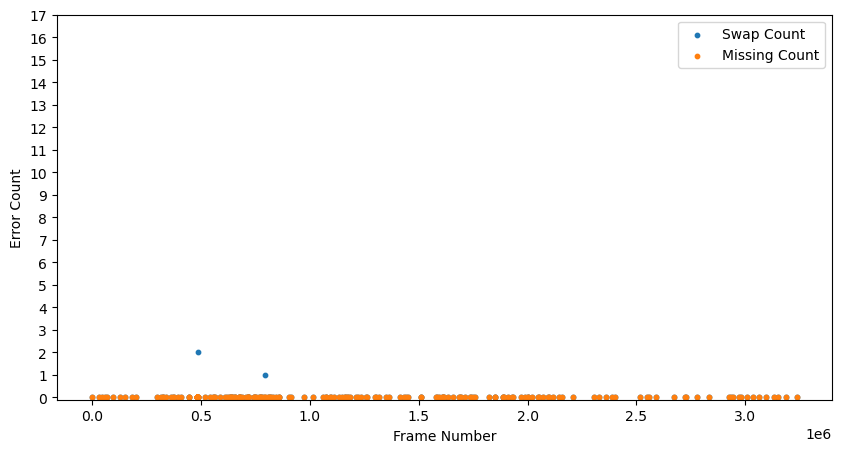

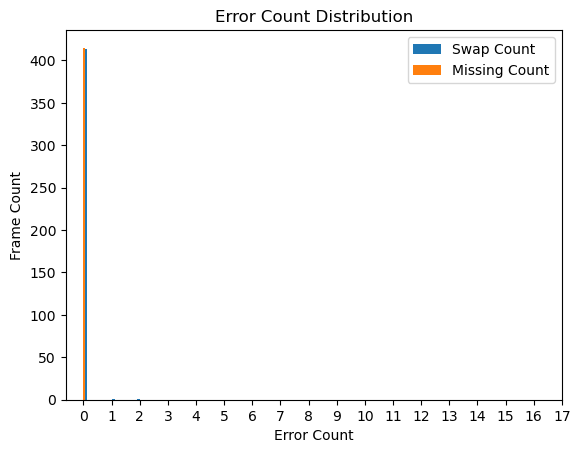

In [15]:
swap_cnt_lst, missing_cnt_lst = eval_discrete_points(test_labeled_points_corrected, test_lbf_indices, method='polygon', count_missing=True)

100%|██████████| 415/415 [00:40<00:00, 10.16it/s]


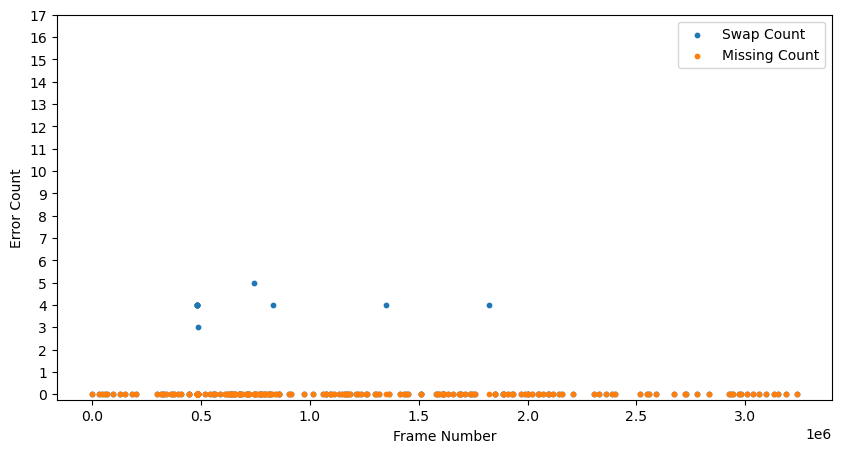

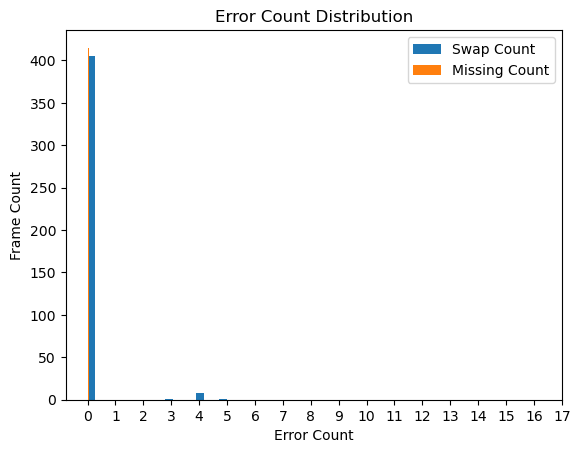

In [50]:
swap_cnt_lst, missing_cnt_lst, _ = eval_discrete_points(test_labeled_points, test_lbf_indices, method='polygon', count_missing=True)

In [55]:
misconstructed_frames_idx = np.where(np.array(swap_cnt_lst) > 0)[0]
misconstructed_frames_idx

array([ 56, 154, 178, 180, 243, 276, 282, 313, 383, 397])

In [65]:
misconstructed_frames = [test_lbf_indices[i] for i in np.where(np.array(swap_cnt_lst) > 0)[0]]
np.sort(misconstructed_frames)

array([ 482310,  482316,  482317,  482339,  482347,  486837,  743664,
        830682, 1347840, 1824120])

In [62]:
from typing import Callable

def plot_multiframe_polygons(points: np.ndarray, poly_constructor: Callable=poly_4):
    assert points.ndim == 3, f'points.ndim: {points.ndim}'
    poly_cnt = len(points)
    polygons = [poly_constructor(pts) for pts in points]
    _, axs = plt.subplots(1, poly_cnt, figsize=(5*poly_cnt, 5))
    if poly_cnt == 1:
        axs = [axs]
    for i, order in enumerate(polygons):
        plot_polygon(points[i], order, axs[i], f'poly_{i+1}')
        axs[i].invert_yaxis() # invert y-axis to put (0,0) at top left
    plt.tight_layout()
    plt.show()
    
    print("\nTotal edge lengths:")
    for i, order in enumerate(polygons):
        print(f"poly_{i+1}: {get_total_edge_length(points[i], order):.3f}")

In [59]:
test_labeled_points[misconstructed_frames_idx[:3]].shape

(3, 17, 2)

[482310 482316 482317]


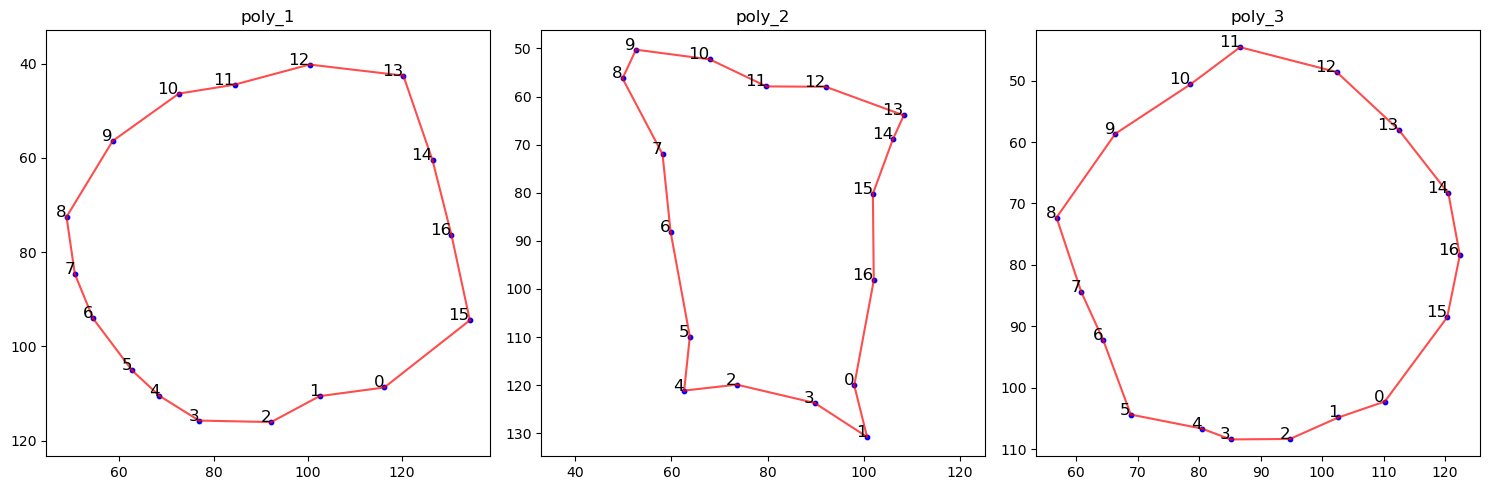


Total edge lengths:
poly_1: 256.448
poly_2: 241.585
poly_3: 199.406


In [63]:
print(misconstructed_frames[:3])
plot_multiframe_polygons(test_labeled_points[misconstructed_frames_idx[:3]])

100%|██████████| 415/415 [00:44<00:00,  9.33it/s]


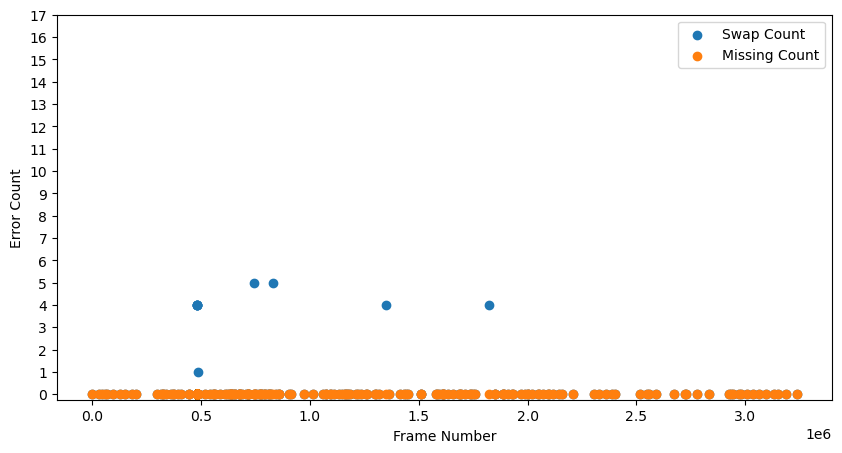

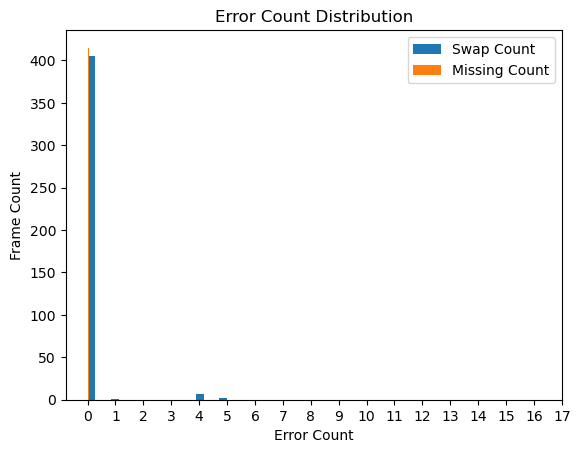

In [54]:
swap_cnt_lst, missing_cnt_lst,filtered_ranges = eval_discrete_points(test_untracked_points, test_lbf_indices, method='polygon', count_missing=True)

## single-animal model

### 4k, uncorrected

### 4k, corrected

In [2]:
save_path = '/home/mingxiao/Desktop/jellyfish/label/predictions/single_model_eval_'
    # np.save(f'{save_path}_swap_cnt_lst.npy', swap_cnt_lst)
    # np.save(f'{save_path}_missing_cnt_lst.npy', missing_cnt_lst)
    # np.save(f'{save_path}_filtered_ranges.npy', filtered_ranges)
swap_cnt_lst = np.load(f'{save_path}_swap_cnt_lst.npy')
missing_cnt_lst = np.load(f'{save_path}_missing_cnt_lst.npy')
filtered_ranges = np.load(f'{save_path}_filtered_ranges.npy')
print(swap_cnt_lst.shape)
print(missing_cnt_lst.shape)
print(filtered_ranges.shape)

(3240000,)
(3240000,)
(17775, 2)


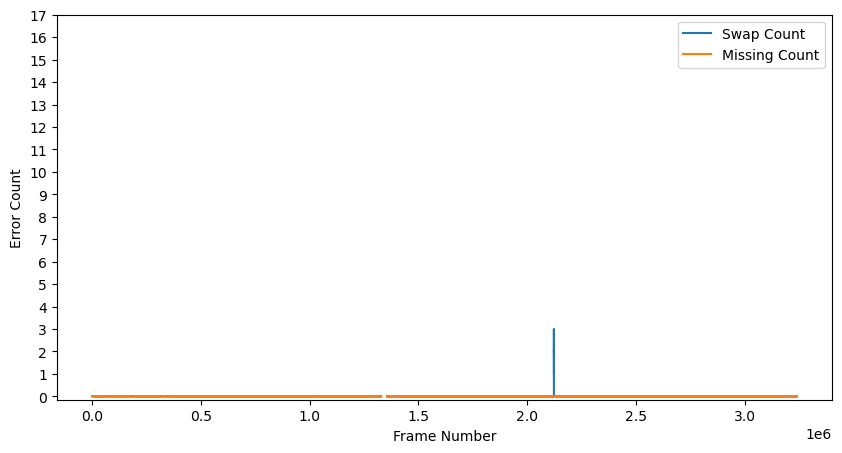

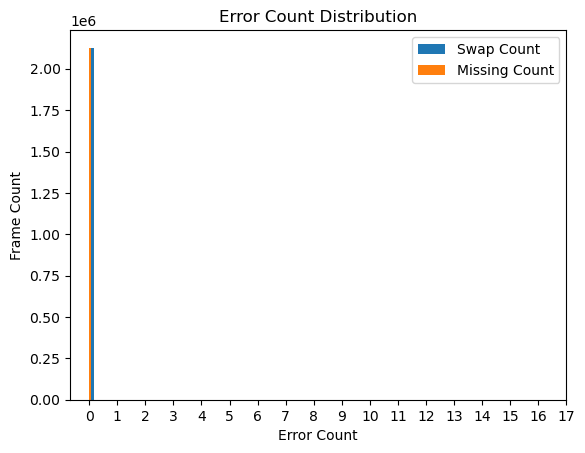

In [3]:
plot_error_count_over_time(swap_cnt_lst, missing_cnt_lst, plot_total=False, tb_cnt=17)
plot_error_count_distribution(swap_cnt_lst, missing_cnt_lst, tb_cnt=17)